In [1]:
!pip install chromadb faiss-cpu qdrant-client sentence-transformers pandas tabulate tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60

the chunks number: 341
the testing queries: 30


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

ChromaDB

FAISS

Qdrant
|          |   Index Time (s) |   Avg Search Latency (ms) | Architecture Type               |
|:---------|-----------------:|--------------------------:|:--------------------------------|
| ChromaDB |           0.3329 |                      1.7  | Embedded (Python / C++ hnswlib) |
| FAISS    |           0.0006 |                      0.06 | In-Memory Vector Library        |
| Qdrant   |           0.0456 |                      2.03 | Local Server Mode (Rust)        |


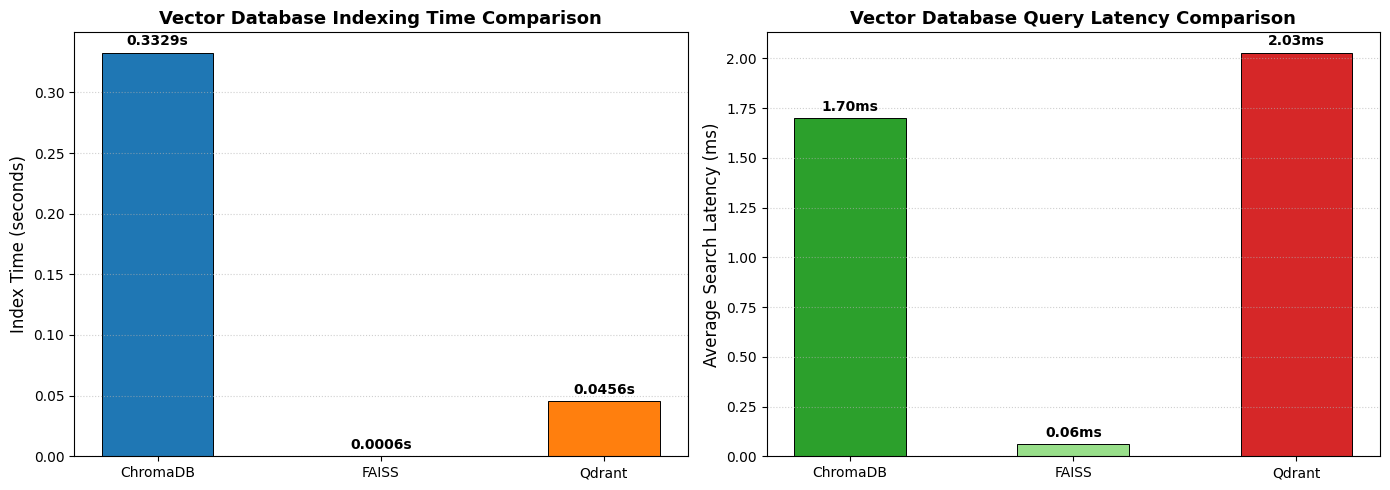

In [3]:
import json
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import chromadb
import faiss
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

assert os.path.exists('/content/parsed_pdf.json'), "file parsed_pdf.json is not found in /content/"
assert os.path.exists('/content/test_dataset.json'), "file test_dataset.json is not found in /content/"

with open('/content/parsed_pdf.json', 'r', encoding='utf-8') as f:
    parsed_data = json.load(f)

with open('/content/test_dataset.json', 'r', encoding='utf-8') as f:
    test_dataset = json.load(f)

documents = [chunk['text'] for chunk in parsed_data]
doc_ids = [f"doc_{i}" for i in range(len(documents))]
num_chunks = len(documents)

queries = [item['query'] for item in test_dataset]

print(f"the chunks number: {num_chunks}")
print(f"the testing queries: {len(queries)}")

model_name = 'intfloat/multilingual-e5-large'
encoder = SentenceTransformer(model_name)
embedding_dim = 1024

prefixed_documents = ["passage: " + doc for doc in documents]
doc_embeddings = encoder.encode(prefixed_documents, show_progress_bar=True)

prefixed_queries = ["query: " + q for q in queries]
query_embeddings = encoder.encode(prefixed_queries, show_progress_bar=False)

top_k = 5
results = {}

print("ChromaDB")
try:
    chroma_client = chromadb.Client()
    chroma_collection = chroma_client.get_or_create_collection(
        name="popatkus_real_collection",
        metadata={"hnsw:space": "cosine"}
    )
    if chroma_collection.count() > 0:
        chroma_collection.delete(ids=doc_ids)

    start_idx = time.time()
    chroma_collection.add(
        embeddings=doc_embeddings.tolist(),
        documents=documents,
        ids=doc_ids
    )
    chroma_idx_time = time.time() - start_idx

    chroma_latencies = []
    for q_emb in query_embeddings:
        start_search = time.time()
        res = chroma_collection.query(query_embeddings=[q_emb.tolist()], n_results=top_k)
        chroma_latencies.append((time.time() - start_search) * 1000)

    chroma_avg_lat = np.mean(chroma_latencies)

    results['ChromaDB'] = {
        'Index Time (s)': round(chroma_idx_time, 4),
        'Avg Search Latency (ms)': round(chroma_avg_lat, 2),
        'Architecture Type': 'Embedded (Python / C++ hnswlib)'
    }
except Exception as e:
    print(f"testing error ChromaDB: {e}")

print("\nFAISS")
try:
    faiss_doc_embeddings = doc_embeddings.copy()
    faiss_query_embeddings = query_embeddings.copy()
    faiss.normalize_L2(faiss_doc_embeddings)
    faiss.normalize_L2(faiss_query_embeddings)

    index = faiss.IndexFlatIP(embedding_dim)

    start_idx = time.time()
    index.add(faiss_doc_embeddings.astype('float32'))
    faiss_idx_time = time.time() - start_idx

    faiss_latencies = []
    for q_emb in faiss_query_embeddings:
        q_emb_reshaped = q_emb.reshape(1, -1).astype('float32')
        start_search = time.time()
        distances, indices = index.search(q_emb_reshaped, top_k)
        faiss_latencies.append((time.time() - start_search) * 1000)

    faiss_avg_lat = np.mean(faiss_latencies)

    results['FAISS'] = {
        'Index Time (s)': round(faiss_idx_time, 4),
        'Avg Search Latency (ms)': round(faiss_avg_lat, 2),
        'Architecture Type': 'In-Memory Vector Library'
    }
except Exception as e:
    print(f"testing error FAISS: {e}")

print("\nQdrant")
try:
    qdrant_client = QdrantClient(":memory:")
    collection_name = "popatkus_real_collection"

    qdrant_client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
    )

    points = [
        PointStruct(
            id=idx,
            vector=doc_embeddings[idx].tolist(),
            payload={"text": documents[idx]}
        ) for idx in range(num_chunks)
    ]

    start_idx = time.time()
    qdrant_client.upload_points(collection_name=collection_name, points=points, wait=True)
    qdrant_idx_time = time.time() - start_idx

    qdrant_latencies = []
    for q_emb in query_embeddings:
        start_search = time.time()
        search_result = qdrant_client.query_points(
            collection_name=collection_name,
            query=q_emb.tolist(),
            limit=top_k
        )
        qdrant_latencies.append((time.time() - start_search) * 1000)

    qdrant_avg_lat = np.mean(qdrant_latencies)

    results['Qdrant'] = {
        'Index Time (s)': round(qdrant_idx_time, 4),
        'Avg Search Latency (ms)': round(qdrant_avg_lat, 2),
        'Architecture Type': 'Local Server Mode (Rust)'
    }
except Exception as e:
    print(f"testing error Qdrant: {e}")

df_results = pd.DataFrame.from_dict(results, orient='index')
print(df_results.to_markdown())

engines = list(results.keys())
index_times = [results[eng]['Index Time (s)'] for eng in engines]
search_latencies = [results[eng]['Avg Search Latency (ms)'] for eng in engines]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors1 = ['#1f77b4', '#aec7e8', '#ff7f0e']
bars1 = ax1.bar(engines, index_times, color=colors1, width=0.5, edgecolor='black', linewidth=0.7)
ax1.set_ylabel('Index Time (seconds)', fontsize=12)
ax1.set_title('Vector Database Indexing Time Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle=':', alpha=0.6)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (max(index_times) * 0.01), f"{yval:.4f}s", ha='center', va='bottom', fontweight='bold')

colors2 = ['#2ca02c', '#98df8a', '#d62728']
bars2 = ax2.bar(engines, search_latencies, color=colors2, width=0.5, edgecolor='black', linewidth=0.7)
ax2.set_ylabel('Average Search Latency (ms)', fontsize=12)
ax2.set_title('Vector Database Query Latency Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + (max(search_latencies) * 0.01), f"{yval:.2f}ms", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('vector_db_benchmarks.png', dpi=300)
plt.show()